# Linear Regression From Scratch in Python


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np




### Read the file and print the content

In [18]:
data = pd.read_csv('Student Learning Dataset/score_updated.csv')
print(data.head())
print(f'Dataset size: {len(data)}')


   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30
Dataset size: 96


### Visualizing the data using matplotlib

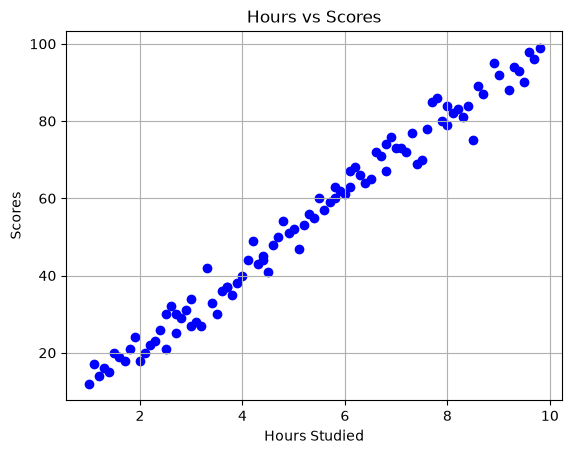

In [19]:
x = data['Hours'].values.reshape(-1, 1)
y = data['Scores'].values

plt.scatter(x, y, color = 'blue', label = None)

plt.title('Hours vs Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.grid(True)
plt.show()




### Coding some functions for linear regression

In [24]:
def loss_function (m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points.iloc[i].Hours
        y = points.iloc[i].Scores
        total_error += (y - (m*x + b)) ** 2
    return total_error / float(len(points))

def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0
    n = len(points)
    for i in range(n):
        x = points.iloc[i].Hours
        y = points.iloc[i].Scores
        m_gradient += -(2/n) * x * (y-(m_now * x + b_now))
        b_gradient += -(2/n) * (y-(m_now * x + b_now))
        
    m = m_now - L * m_gradient
    b = b_now - L * b_gradient
    
    return m, b

m, b = 0, 0
L = 0.0001
epochs = 1000
for i in range(epochs):
    m, b = gradient_descent(m, b, data, L)
    if i % 100 == 0:
        print(f'Epoch {i}: m = {m}, b = {b}, loss = {loss_function(m, b, data)}')
print(f'Final parameters: m = {m}, b = {b}, loss = {loss_function(m, b, data)}')


Epoch 0: m = 0.069190625, b = 0.010804166666666665, loss = 3488.733956861755
Epoch 100: m = 5.032487499817292, b = 0.7861462250056294, loss = 872.738096717094
Epoch 200: m = 7.5024410403994946, b = 1.1725569429898492, loss = 224.8432594021995
Epoch 300: m = 8.7315548821709, b = 1.3654096901622066, loss = 64.38126875880678
Epoch 400: m = 9.343151370827746, b = 1.4619342010633245, loss = 24.640104047021953
Epoch 500: m = 9.64743379438647, b = 1.510517940085357, loss = 14.797453876804768
Epoch 600: m = 9.798778263733958, b = 1.5352414733236655, loss = 12.359667151381307
Epoch 700: m = 9.87401176415774, b = 1.5480887689140908, loss = 11.755818266282896
Epoch 800: m = 9.911368097190733, b = 1.5550237886260463, loss = 11.606175134672847
Epoch 900: m = 9.929874737786951, b = 1.5590145711667778, loss = 11.569024227105986
Final parameters: m = 9.93893811582043, b = 1.5615174230742535, loss = 11.55977813009479


### Drawing the linear regression line

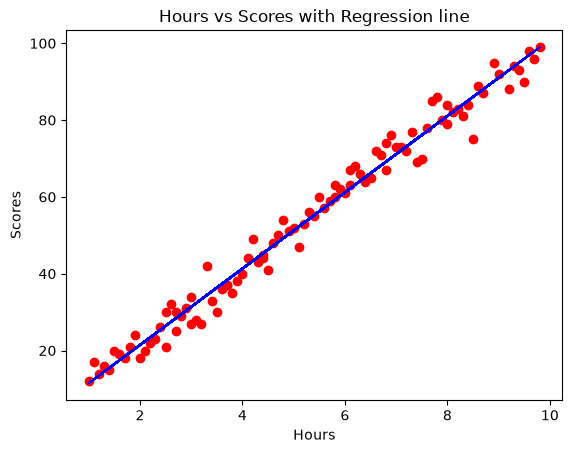

In [25]:
plt.scatter(data.Hours, data.Scores, color = 'red')
x_line = data.Hours
y_line = m * x_line + b
plt.plot(x_line, y_line, color = 'blue')
plt.title('Hours vs Scores with Regression line')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.show()
